# EnergyNet Tutorial

Welcome to **EnergyNet**, a smart-grid simulation package built around Gymnasium environments and reinforcement-learning agents. This notebook develops the system in three layers so that each new concept has a concrete foundation.

| Part | Question it answers | Main environment |
|---|---|---|
| PCS | How should a household use its battery when prices and demand change? | `PCSEnv` |
| ISO | How should a grid operator choose prices and dispatch targets for a day? | `ISOEnv` |
| Alternating ISO-PCS | What happens when the grid operator and household learn in response to each other? | `AlternatingISOEnv` |

You will first run a simple baseline policy, then train and evaluate agents, and finally connect both sides of the market. Training cells can take time; the explanatory and short simulation cells are useful on their own.

**Author:** Michael Wein  
**GitHub:** [energy-net](https://github.com/CLAIR-LAB-TECHNION/energy-net)

## 1. Setup

Run this notebook from the root of an existing local clone. In Google Colab, the next cell clones the repository only when it is not already present. The setup is non-destructive: it never removes an existing checkout. The following cell installs EnergyNet with its reinforcement-learning dependencies.

In [ ]:
from pathlib import Path
import os
import subprocess

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    repository_root = Path("/content/energy-net")
    if not repository_root.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "https://github.com/CLAIR-LAB-TECHNION/energy-net.git",
                str(repository_root),
            ],
            check=True,
        )
    os.chdir(repository_root)
else:
    repository_root = Path.cwd()
    if not (repository_root / "pyproject.toml").exists():
        raise RuntimeError(
            "Run this notebook from the root of the cloned energy-net repository."
        )

print(f"Using repository: {repository_root}")

In [ ]:
%pip install -e ".[rl]"

In [ ]:
import warnings
warnings.simplefilter("ignore") #To ignore warnings about your Python version or other silly things that clutter up the output.

# 2. PCS Environment: Household and Battery Decisions

A **PCS** combines three kinds of grid components:

- **Production** generates energy, such as solar panels or turbines.
- **Consumption** uses energy, such as household appliances or industrial loads.
- **Storage** holds energy for later, such as a battery.

This tutorial uses a deliberately small PCS: **one consumption unit, one battery, and no local production**. The external grid supplies energy at a time-varying price. The PCS can buy energy to charge the battery or sell stored energy back to the grid; in this standalone environment, buying and selling use the same price.

```text
consumption forecast + battery state + current price
                         |
                         v
                    PCS observation --> agent action
                                           |
                              + charge/buy | discharge/sell -
                                           v
                              battery supplies household demand
                                           |
                                           v
                              money earned - shortage penalty
```

The price curve is part of the environment for now, so the PCS agent controls only the battery action. Later, the ISO agent will generate the prices.

| Concept | Meaning in `PCSEnv` |
|---|---|
| Observation | Current storage, consumption, price, forecast window, forecast-validity mask, battery limits, and optional features |
| Action | One value in `[-10, 10]`: positive charges/buys; negative discharges/sells |
| Reward | Money earned from energy trades minus a configurable shortage penalty |
| Forecast source | Precomputed consumption predictions produced by the repository-root `prediction` package |

The agent therefore has two linked goals: trade energy economically and keep enough stored energy to meet demand.

## 2.1 Create a Basic PCS Environment

The constructor connects the simulator to actual-consumption data and forecast data. The most important arguments in this example are:

| Argument | Purpose |
|---|---|
| `render_mode='human'` | Enables readable state reports from `env.render()` |
| `test_data_file` | Supplies the consumption that actually occurs |
| `predictions_file` | Supplies the forecast visible to the agent |
| `shortage_penalty` | Deducts reward when stored energy cannot cover demand; its scale should be meaningful relative to energy prices |

The example uses repository test fixtures so it can run without preparing a separate dataset.

In [ ]:
import numpy as np

from energy_net.gym_envs.pcs_env import PCSEnv

env = PCSEnv(
    render_mode="human",
    test_data_file="tests/gym/data_for_tests/synthetic_household_consumption_test.csv",
    predictions_file="tests/gym/data_for_tests/consumption_predictions_without_features.csv",
    shortage_penalty=1,
)

Loaded 7008 aligned predictions
Detected 0 feature columns: []
Creating consumption unit on testing data...
Observation space dimension: 101
  - Base features (storage, consumption, price): 3
  - Zero-padded predictions + validity mask: 96
  - Battery capacity constraints: 2
  - Additional time features: 0


## 2.2 Understand Episode Timing

For this tutorial, one episode is one day. The default interval is 30 minutes, so each episode contains 48 calls to `step()`.

| Episode position | Clock time | Step count |
|---|---:|---:|
| Start | 00:00 | 0 |
| Midpoint | 12:00 | 24 |
| End | 24:00 | 48 |

The `dt` and `episode_length_days` constructor arguments can change this resolution and duration, but all examples below use the defaults. Each call to `env.reset()` starts the next day in the data; after the final available day, the environment loops back to the beginning.

In [ ]:
# Reset at the start of each day.
# This clears financial metrics and ensures the strategy starts fresh for the date.
obs, info = env.reset()
env.render()


[PCS Step 0/48] 2025-07-09 00:00
Storage:               0.00 / 100.0 units
Consumption:           3.19 units/step
Price (SineWavePriceStrategy): $0.1000/unit
--- Episode Running Totals ---
Money:     $0.00
Penalties: $0.00
Net:       $0.00
Shortages: 0


{'step': 0,
 'max_steps': 48,
 'datetime': Timestamp('2025-07-09 00:00:00'),
 'storage': 0,
 'consumption': np.float64(3.19168),
 'price': 0.10000000149011612,
 'strategy': 'SineWavePriceStrategy',
 'last_action': None,
 'total_money': 0.0,
 'total_penalty': 0.0,
 'total_reward': 0.0,
 'shortage_count': 0}

## 2.3 Try a Simple Baseline

Before training an agent, run a policy whose behavior is easy to predict:

- During the first 24 half-hour steps, request **+10 units** to charge the battery (buy from the grid).
- During the next 24 steps, request **-5 units** to discharge the battery (sell to the grid).

These are requested actions, not guarantees. The battery clips them to physical limits: it cannot charge beyond its maximum capacity or discharge more energy than it currently stores. This simple baseline is intentionally not optimal; it makes the action sign, storage limits, prices, rewards, and shortages visible in the rendered output.

In [ ]:
print(f"Date: {env.current_datetime.strftime('%Y-%m-%d')}")

day_reward = 0.0
time_step = 0


# Intra-day time steps (48 steps per day, one for each half hour)
while True:
  # Follow the deterministic baseline described above.
  # Positive values charge/buy; negative values discharge/sell.
  action_value = 10 if time_step < 24 else -5
  action = np.array([action_value], dtype=np.float32)

  # Step the simulation.
  # The env will internally query the PriceCurveStrategy for the current price,
  # calculate the financial reward, and update the battery/consumption state.
  obs, reward, terminated, truncated, info = env.step(action)
  # Render all the details of the current time slot
  env.render()

  # Accumulate rewards (net financial performance).
  day_reward += reward

  print(f"Step Reward: {reward:.2f}")

  # Check for end of day
  # Terminated becomes True once the current_step reaches max_steps (48).
  if terminated or truncated:
      print(f"\n>>> Day Finished!")
      print(f">>> Total Day Reward: {day_reward:.2f}")
      print(f">>> Final Storage: {info['storage_after_units']:.2f} units")
      print(f">>> Total Shortages Today: {env.shortage_count}")
      break
  time_step+=1

Date: 2025-07-09

[PCS Step 1/48] 2025-07-09 00:30
Storage:               6.81 / 100.0 units
Consumption:           3.19 units/step
Price (SineWavePriceStrategy): $0.1196/unit
Battery Action:        10.00 units
--- Episode Running Totals ---
Money:     $-1.00
Penalties: $0.00
Net:       $-1.00
Shortages: 0
Step Reward: -1.00

[PCS Step 2/48] 2025-07-09 01:00
Storage:               13.81 / 100.0 units
Consumption:           3.00 units/step
Price (SineWavePriceStrategy): $0.1388/unit
Battery Action:        10.00 units
--- Episode Running Totals ---
Money:     $-2.20
Penalties: $0.00
Net:       $-2.20
Shortages: 0
Step Reward: -1.20

[PCS Step 3/48] 2025-07-09 01:30
Storage:               21.01 / 100.0 units
Consumption:           2.79 units/step
Price (SineWavePriceStrategy): $0.1574/unit
Battery Action:        10.00 units
--- Episode Running Totals ---
Money:     $-3.58
Penalties: $0.00
Net:       $-3.58
Shortages: 0
Step Reward: -1.39

[PCS Step 4/48] 2025-07-09 02:00
Storage:         

## 2.4 Read Observations and Step Diagnostics

The agent receives a numeric observation, while the `info` dictionary returned by `step()` exposes human-readable diagnostics. Keeping those two roles separate is useful when debugging a policy.

**Observation groups**

| Group | What it tells the agent |
|---|---|
| Current state | Normalized storage, current consumption, and current price |
| Forecast window | Predicted future consumption, zero-padded beyond the episode boundary |
| Validity mask | Which forecast entries belong to the current episode |
| Battery limits | Available charge and discharge capacity |
| Optional features | Extra columns supplied by the prediction CSV |

**Useful `info` fields** include storage before and after the transition, the applied battery action, current price, step money, consumption, available discharge, and whether a shortage occurred.

## 2.5 Follow One Transition

Consider a simplified step with 5 stored units, a price of 0.1 per unit, demand of 3 units, and an action of +1 unit.

1. **Apply the action.** The PCS buys 1 unit, costing `1 x 0.1 = 0.1`, so storage temporarily becomes `5 + 1 = 6`.
2. **Meet demand.** The consumption unit uses 3 units, leaving `6 - 3 = 3` in storage.
3. **Compute reward.** The voluntary +1-unit purchase makes `step_money = -0.1`. For these values, the environment's shortage flag is false, so no shortage penalty is subtracted and the step reward is `-0.1`.
4. **Advance time.** The environment moves forward by one 30-minute interval and returns the next observation.

```text
storage before -> apply battery action -> serve consumption -> storage after
      5                  +1                   -3              3
```

The order matters near capacity limits and when storage is nearly empty, so it is important to read the action as an instruction applied **before the current step's demand is served**.

### Action Sign and Planning Ahead

- **Positive action:** charge the battery, which means buying energy from the grid.
- **Negative action:** discharge the battery, which means selling stored energy to the grid.
- **Zero action:** make no voluntary battery trade; the battery may still discharge internally to serve consumption.

Although the action is applied before demand in the same transition, a good policy still plans ahead. Forecasts help it avoid reaching an expensive or high-demand interval with too little stored energy.

### Daily Battery Reset

`PCSEnv` resets the battery to **0 units at the start of each day**. Each episode is therefore a self-contained planning problem: the agent cannot accumulate cheap energy across days, and end-of-day storage does not carry into the next episode.

## 2.6 Train a PCS Agent

The simple baseline helps explain the mechanics; the next cells let a Soft Actor-Critic (SAC) agent learn its own battery policy from repeated interaction. `TRAIN_TIMESTEPS` controls training cost. Keep it small while checking the workflow, then increase it only when you want a more meaningful policy.

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from stable_baselines3 import SAC
warnings.simplefilter("ignore") #To ignore warnings about your Python version or other silly things that clutter up the output.

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
# ---------------- CONFIG ----------------
TRAIN_TIMESTEPS = 10000   # lower for quick tests; raise for serious training
EVAL_DAYS = 3              # how many days to evaluate after training
SEED = 42

# Create SAC model (device='auto' will use GPU in Colab if available)
model = SAC("MlpPolicy", env, verbose=0, seed=SEED, device="auto")

# Train
print("Starting training... (this may take a while depending on TRAIN_TIMESTEPS)")
model.learn(total_timesteps=TRAIN_TIMESTEPS)
print("Training finished.")


## 2.7 Evaluate the Learned PCS Policy

Training reward alone does not explain what the policy learned. The evaluation loop runs the deterministic policy for `EVAL_DAYS` and records storage, prices, actions, money, consumption, and shortages at every half-hour step. The following plots answer concrete questions:

- Does storage rise before expensive or high-demand periods?
- Do actions respect the expected positive/negative sign?
- Does cumulative money improve without creating shortages?
- Are repeated days behaving consistently?

Try changing training settings only after this baseline evaluation works, so comparisons remain interpretable.

In [ ]:
# ---------------- EVALUATION ----------------
env_eval = PCSEnv(render_mode='human', test_data_file='tests/gym/data_for_tests/synthetic_household_consumption_test.csv',
                 predictions_file='tests/gym/data_for_tests/consumption_predictions_without_features.csv',shortage_penalty = 1)
# Prepare storage for metrics
timestamps = []
storage_before = []
storage_after = []
prices = []
actions = []
step_money = []
total_money = []
shortages = []
consumptions = []
avail_discharges = []

num_days = EVAL_DAYS
steps_per_day = env_eval.max_steps  # usually 48 for dt=0.5/24

for day in range(num_days):
    # reset returns (obs, info) in Gymnasium
    obs, info = env_eval.reset()
    done = False
    while not done:
        # predict action pass only the observation
        action, _state = model.predict(obs, deterministic=True)

        # Step env and unpack Gymnasium outputs
        next_obs, reward, terminated, truncated, info = env_eval.step(action)
        done = bool(terminated or truncated)

        # timestamp corresponding to the step (env.current_datetime has already advanced)
        ts = env_eval.current_datetime - timedelta(days=env_eval.dt)

        # Log metrics
        timestamps.append(ts)
        storage_before.append(info.get("storage_before_units"))
        storage_after.append(info.get("storage_after_units"))
        prices.append(info.get("current_price"))
        actions.append(float(info.get("battery_action", action[0] if hasattr(action, "__len__") else float(action))))
        step_money.append(info.get("step_money", 0.0))
        total_money.append(info.get("total_money_so_far", env_eval.get_money()))
        shortages.append(1 if info.get("shortage", False) else 0)
        consumptions.append(info.get("consumption_units", 0.0))
        avail_discharges.append(info.get("available_discharge_units", 0.0))

        obs = next_obs

print("Evaluation finished. Collected steps:", len(timestamps))

# Put into DataFrame
df = pd.DataFrame({
    "timestamp": timestamps,
    "storage_before": storage_before,
    "storage_after": storage_after,
    "price": prices,
    "action": actions,
    "step_money": step_money,
    "total_money": total_money,
    "shortage": shortages,
    "consumption": consumptions,
    "available_discharge": avail_discharges
})
df.head()


Loaded 7008 aligned predictions
Detected 0 feature columns: []
Creating consumption unit on testing data...
Observation space dimension: 101
  - Base features (storage, consumption, price): 3
  - Zero-padded predictions + validity mask: 96
  - Battery capacity constraints: 2
  - Additional time features: 0
Evaluation finished. Collected steps: 144


,timestamp,storage_before,storage_after,price,action,step_money,total_money,shortage,consumption,available_discharge
0,2025-07-09 00:00:00,0.000000,6.438371,0.100000,9.630051,-0.963005,-0.963005,0,3.19168,6.438371
1,2025-07-09 00:30:00,6.438371,12.927612,0.119579,9.489401,-1.134732,-2.097737,0,3.00016,12.927612
2,2025-07-09 01:00:00,12.927612,19.513977,0.138823,9.380196,-1.302186,-3.399923,0,2.79383,19.513977
3,2025-07-09 01:30:00,19.513977,26.206616,0.157403,9.225929,-1.452184,-4.852107,0,2.53329,26.206616
4,2025-07-09 02:00:00,26.206616,32.749090,0.175000,8.953283,-1.566825,-6.418932,0,2.41081,32.749090


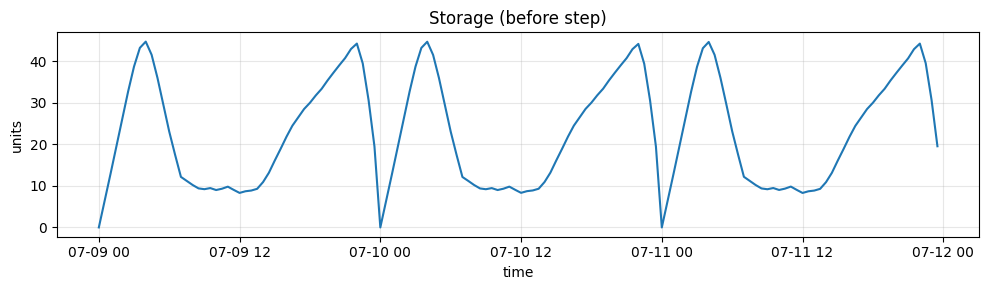

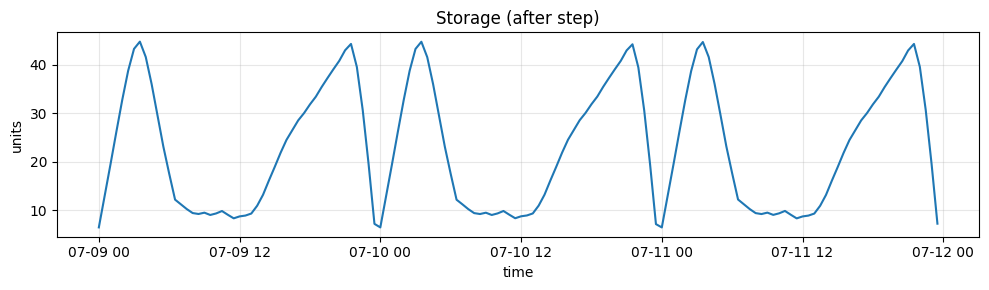

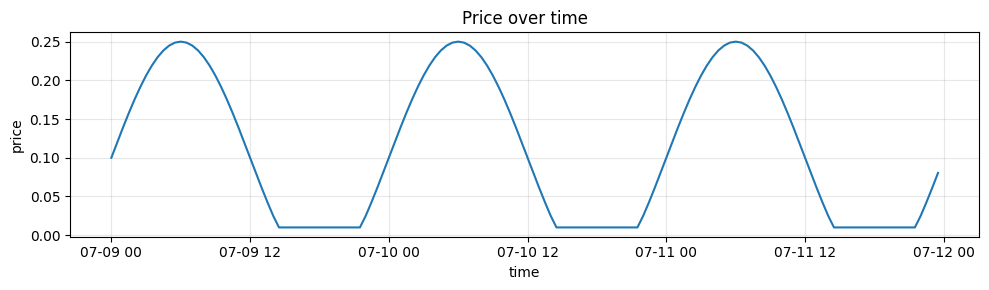

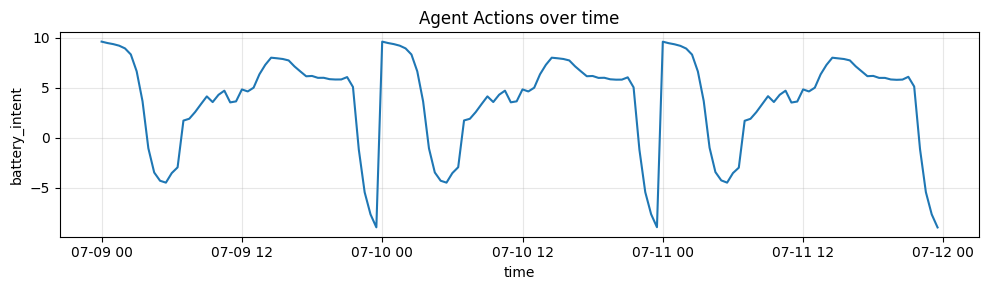

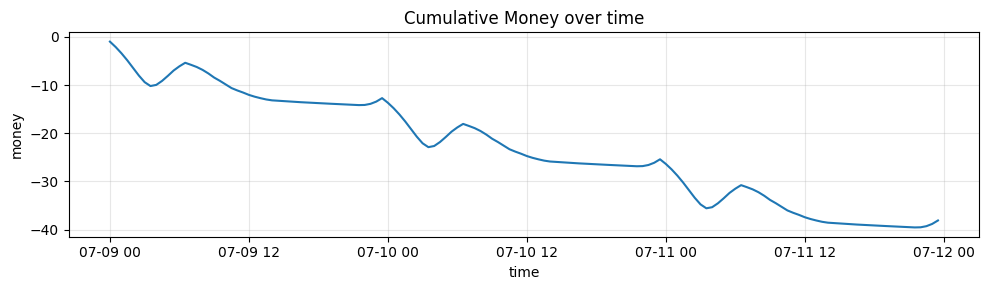

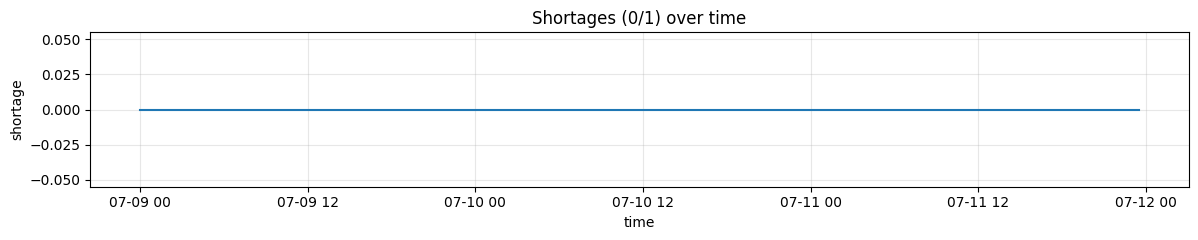

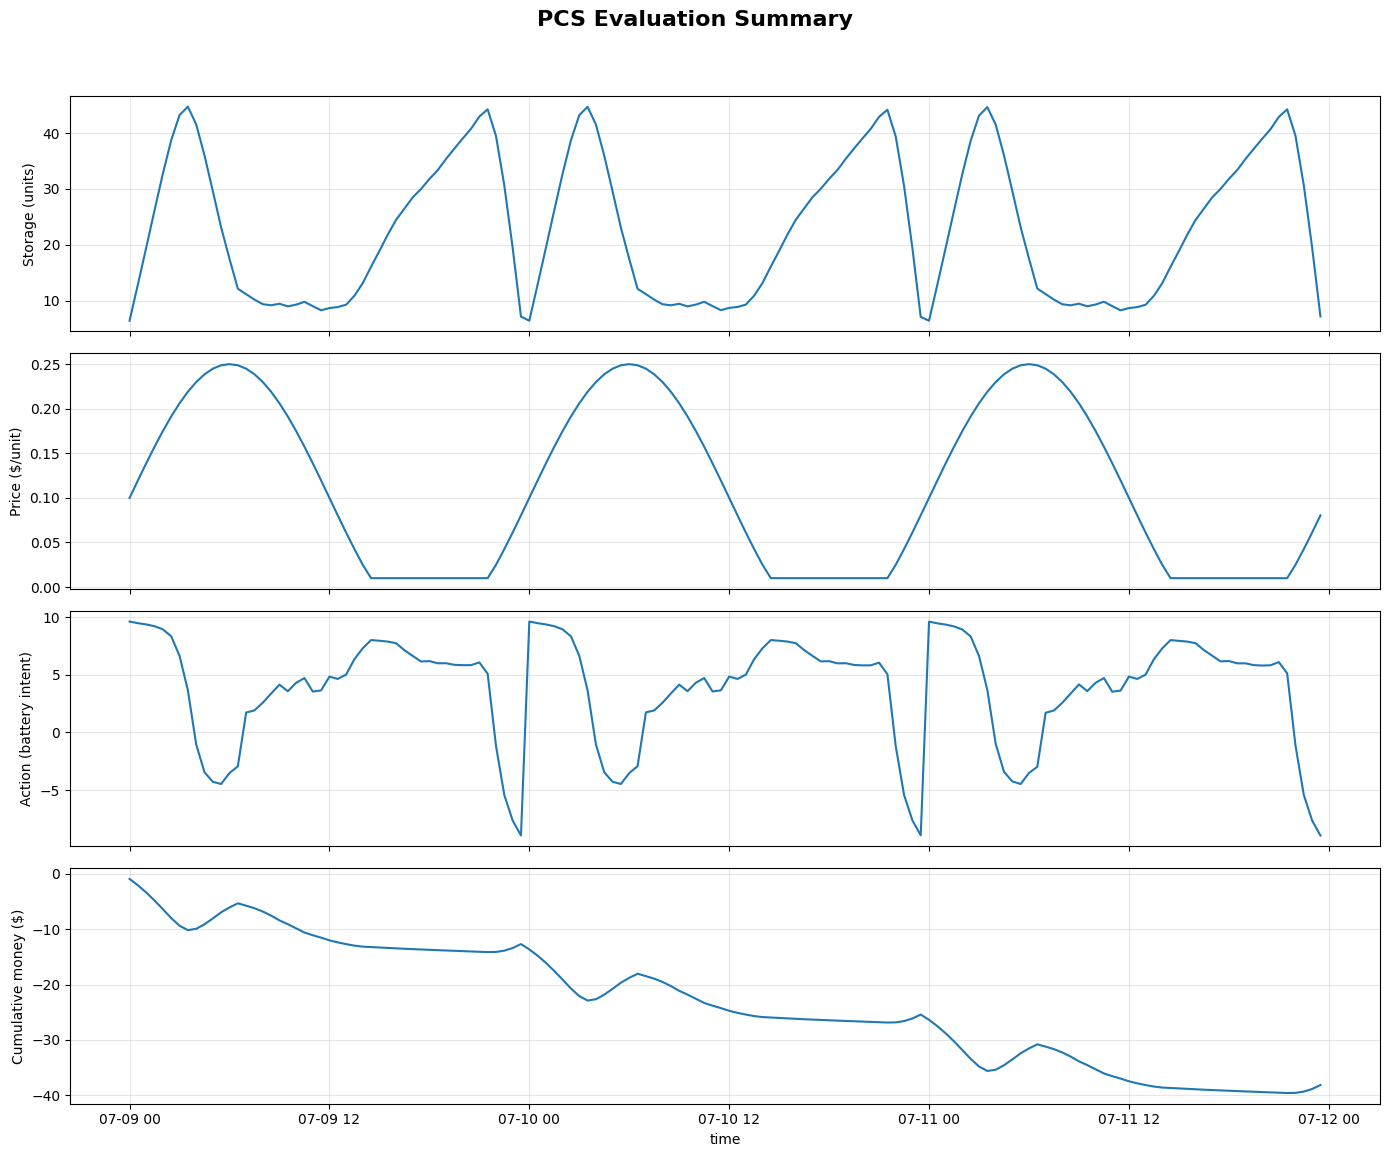

In [ ]:
# ---------- SIMPLE SINGLE PLOTS ----------
def line_plot(x, y, title, xlabel="timestep", ylabel=None, figsize=(10,3)):
    plt.figure(figsize=figsize)
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# storage before/after
line_plot(df['timestamp'], df['storage_before'], "Storage (before step)", xlabel="time", ylabel="units")
line_plot(df['timestamp'], df['storage_after'],  "Storage (after step)",  xlabel="time", ylabel="units")

# price
line_plot(df['timestamp'], df['price'], "Price over time", xlabel="time", ylabel="price")

# actions
line_plot(df['timestamp'], df['action'], "Agent Actions over time", xlabel="time", ylabel="battery_intent")

# money (cumulative)
df['cumulative_money'] = df['step_money'].cumsum()
line_plot(df['timestamp'], df['cumulative_money'], "Cumulative Money over time", xlabel="time", ylabel="money")

# shortages as step plot
plt.figure(figsize=(12,2.5))
plt.plot(df['timestamp'], df['shortage'], drawstyle='steps-post')
plt.title("Shortages (0/1) over time")
plt.xlabel("time")
plt.ylabel("shortage")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- COMBINED MULTI-PANEL SUMMARY ----------
fig, axes = plt.subplots(4, 1, figsize=(14,12), sharex=True)
fig.suptitle("PCS Evaluation Summary", fontsize=16, fontweight='bold')

axes[0].plot(df['timestamp'], df['storage_after'])
axes[0].set_ylabel("Storage (units)")
axes[0].grid(alpha=0.3)

axes[1].plot(df['timestamp'], df['price'])
axes[1].set_ylabel("Price ($/unit)")
axes[1].grid(alpha=0.3)

axes[2].plot(df['timestamp'], df['action'])
axes[2].set_ylabel("Action (battery intent)")
axes[2].grid(alpha=0.3)

axes[3].plot(df['timestamp'], df['cumulative_money'])
axes[3].set_ylabel("Cumulative money ($)")
axes[3].set_xlabel("time")
axes[3].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

# 3. ISO Environment: Day-Ahead Grid Decisions

The **ISO** (Independent System Operator) acts at a different time scale from the PCS. Instead of choosing one battery action every half hour, `ISOEnv` chooses a complete 48-slot plan for one day.

```text
48-slot consumption forecast (+ optional features)
                       |
                       v
        ISO action: 48 price controls + 48 dispatch controls
                       |
                       v
       compare dispatched energy with actual consumption
                       |
                       v
                 reward = -MAE
```

A useful analogy is planning tomorrow's train schedule: the forecast estimates how many passengers will arrive in each time slot, dispatch determines how much capacity to provide, and the score measures how far the plan was from actual demand. Prices are produced alongside dispatch for later market interaction.

## 3.1 Data, Observation, Action, and Reward

| Element | Shape and role |
|---|---|
| Actual-consumption CSV | The realized demand used to score dispatch |
| Prediction CSV | 48 forecast values plus any automatically detected feature columns |
| Observation | The full daily forecast and flattened optional features |
| Action | 96 normalized controls in `[0, 1]`: 48 prices followed by 48 dispatch values; the environment applies its configured scales |
| Reward | Negative mean absolute error (MAE) between scaled dispatch and actual consumption, so values closer to zero are better |

One call to `step()` processes the whole day and then advances to the next 48-row block. The examples again use repository test fixtures.

In [ ]:
from energy_net.gym_envs.iso_env import ISOEnv

warnings.simplefilter("ignore")

env = ISOEnv(
    actual_csv="tests/gym/data_for_tests/synthetic_household_consumption_test.csv",
    predicted_csv="tests/gym/data_for_tests/consumption_predictions_without_features.csv",
    steps_per_day=48,
)

## 3.2 Run One ISO Day by Hand

The next cell makes the data flow explicit: reset the environment, take the first 48 observation values as consumption predictions, create a rising price curve, use the predictions as dispatch controls, combine both halves into one action, and process one day. This is a demonstration action rather than a claim of optimal grid operation.

In [ ]:
import numpy as np

# Reset to get the first day's observation
obs, info = env.reset()

# The observation contains predictions + features
# Let's extract just the predictions (first 48 values)
predictions = obs[:48]

# Create a simple action: prices and dispatch amounts
prices = np.linspace(0.1, 0.5, 48)  # Prices from $0.10 to $0.50
dispatch = predictions  # Dispatch exactly what we predicted

# Combine into action: [48 prices, 48 dispatch values]
action = np.concatenate([prices, dispatch])

# Take a step (simulate one day)
next_obs, reward, terminated, truncated, step_info = env.step(action)

# Visualize the results
env.render()



--- [DAY] ---
CSV Row Range: 2 to 49
Calendar Date: 2025-07-09
Time       | CSV Row  | Pred     | Actual   | Dispatch   | Price 
----------------------------------------------------------------------
00:00      | 2        | 3.549    | 3.192    | 21.292     | 0.10  
02:00      | 6        | 2.683    | 2.411    | 16.100     | 0.13  
04:00      | 10       | 2.468    | 2.126    | 14.807     | 0.17  
06:00      | 14       | 2.585    | 2.076    | 15.507     | 0.20  
08:00      | 18       | 3.730    | 3.406    | 22.380     | 0.24  
10:00      | 22       | 4.757    | 3.998    | 28.543     | 0.27  
12:00      | 26       | 5.392    | 4.451    | 32.353     | 0.30  
14:00      | 30       | 5.725    | 5.056    | 34.352     | 0.34  
16:00      | 34       | 5.731    | 5.105    | 34.384     | 0.37  
18:00      | 38       | 5.440    | 4.418    | 32.639     | 0.41  
20:00      | 42       | 4.871    | 4.039    | 29.224     | 0.44  
22:00      | 46       | 4.293    | 3.594    | 25.760     | 0.47  
-------

{'csv_range': (2, 49),
 'calendar_date': Timestamp('2025-07-09 00:00:00'),
 'rows': [{'slot_time': Timestamp('2025-07-09 00:00:00'),
   'row_num': 2,
   'pred': 3.548694133758545,
   'actual': 3.1916799545288086,
   'dispatch': 21.292163848876953,
   'price': 0.10000000149011612},
  {'slot_time': Timestamp('2025-07-09 00:30:00'),
   'row_num': 3,
   'pred': 3.3493525981903076,
   'actual': 3.000159978866577,
   'dispatch': 20.096115112304688,
   'price': 0.10851063579320908},
  {'slot_time': Timestamp('2025-07-09 01:00:00'),
   'row_num': 4,
   'pred': 3.1156680583953857,
   'actual': 2.793829917907715,
   'dispatch': 18.694007873535156,
   'price': 0.11702127754688263},
  {'slot_time': Timestamp('2025-07-09 01:30:00'),
   'row_num': 5,
   'pred': 2.8884758949279785,
   'actual': 2.533289909362793,
   'dispatch': 17.330856323242188,
   'price': 0.12553191184997559},
  {'slot_time': Timestamp('2025-07-09 02:00:00'),
   'row_num': 6,
   'pred': 2.6833701133728027,
   'actual': 2.41080999

### Understand `env.render()`

The rendered day report connects array positions back to domain concepts:

- **Time slot / CSV row:** where the half-hour value came from.
- **Predicted vs. actual consumption:** forecast quality for that slot.
- **Dispatch:** the supply target selected by the action.
- **Price:** the scaled price produced by the first action half.
- **Features:** optional weather, calendar, or other prediction columns.
- **MAE:** average absolute dispatch error across the day; lower is better.

## 3.3 Train an ISO Agent

The short SAC run below demonstrates the API, not a converged policy. Because an ISO episode is already one full day, only a few timesteps are enough to exercise the training loop.

In [ ]:
from stable_baselines3 import SAC

# Train an agent
model = SAC(
    "MlpPolicy",
    env,
    gamma=0.0,       # <-- critical
    learning_starts=0,
    train_freq=1,
    gradient_steps=1000,
    verbose=0,
)
model.learn(total_timesteps=3)



## 3.4 Inspect the ISO Policy

The next cell evaluates ten days and plots three signals together: actual consumption, model dispatch, and ISO price. Read the graph in that order: first check whether dispatch follows demand, then inspect how prices vary across the same slots.

Do not expect a strong policy from the tiny training run. Standalone `ISOEnv` uses negative dispatch MAE as its reward and does not yet observe a responding PCS household. The coupled environment in the next section provides that market interaction.


--- [DAY] ---
CSV Row Range: 194 to 241
Calendar Date: 2025-07-13
Time       | CSV Row  | Pred     | Actual   | Dispatch   | Price 
----------------------------------------------------------------------
00:00      | 194      | 3.586    | 3.136    | 2.979      | 0.51  
02:00      | 198      | 2.878    | 2.470    | 3.017      | 0.51  
04:00      | 202      | 2.667    | 2.077    | 2.974      | 0.49  
06:00      | 206      | 2.753    | 2.138    | 2.992      | 0.50  
08:00      | 210      | 3.869    | 3.612    | 3.039      | 0.50  
10:00      | 214      | 4.891    | 4.504    | 2.994      | 0.49  
12:00      | 218      | 5.436    | 4.815    | 3.057      | 0.50  
14:00      | 222      | 5.756    | 5.369    | 3.016      | 0.50  
16:00      | 226      | 5.673    | 5.362    | 3.020      | 0.49  
18:00      | 230      | 5.397    | 4.675    | 3.028      | 0.51  
20:00      | 234      | 4.849    | 4.177    | 3.047      | 0.49  
22:00      | 238      | 4.280    | 3.640    | 3.035      | 0.50  
----

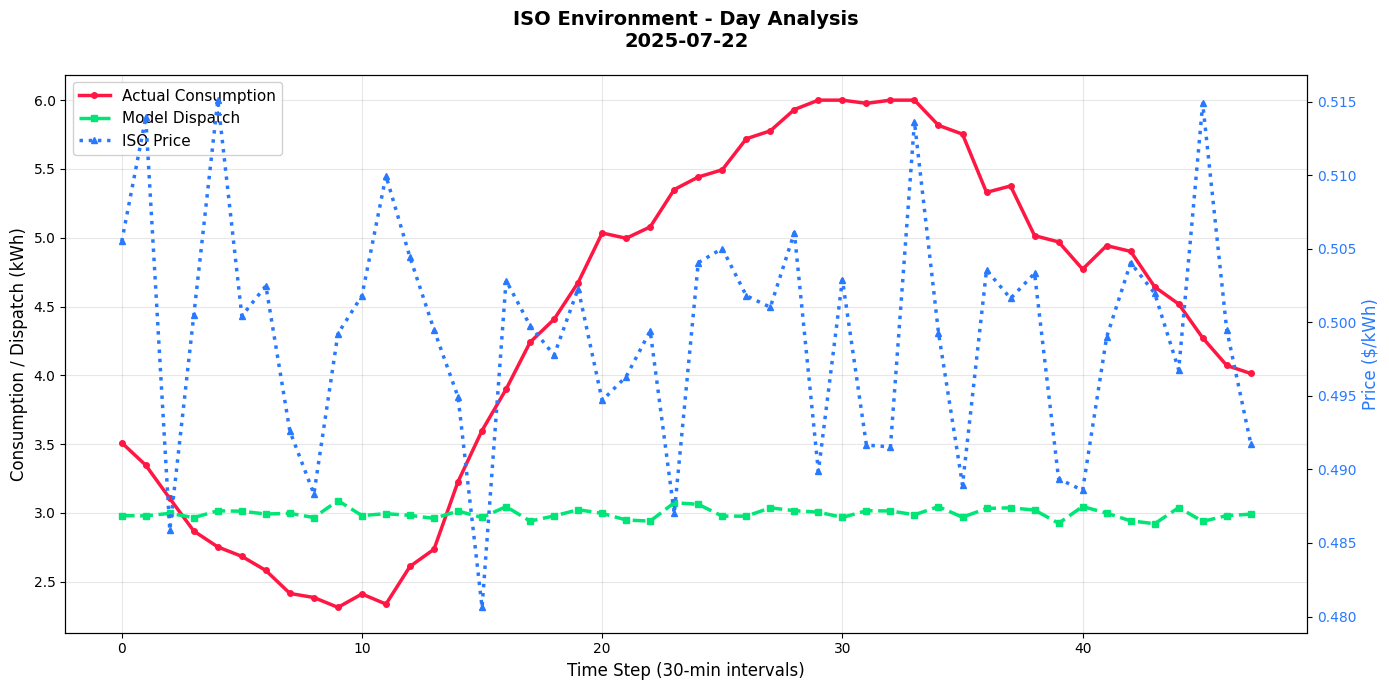


Day Summary for 2025-07-22
Mean Absolute Error (MAE): 1.5672 kWh
Average Price Set:         $0.4993/kWh
Total Actual Consumption:  209.30 kWh
Total Dispatch:            143.80 kWh



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the last day's data from the environment's render record
# Run this cell after your training/testing loop

# First, let's capture data during the test loop
obs, info = env.reset()
day_records = []

for day in range(10):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    record = env.render()

    # Store the record for plotting
    if record is not None:
        day_records.append({
            'actual': info['realized'],
            'dispatch': info['dispatch'],
            'prices': info['prices'],
            'timestamp': info['timestamp']
        })

    if terminated:
        obs, info = env.reset()

# Now plot the last day (or any specific day)
day_to_plot = -1  # -1 for last day, 0 for first day, etc.

if day_records:
    data = day_records[day_to_plot]

    # Create time steps (48 half-hour intervals)
    timesteps = np.arange(len(data['actual']))

    # Create figure with all three metrics
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot actual consumption and dispatch on left y-axis
    ax1.set_xlabel('Time Step (30-min intervals)', fontsize=12)
    ax1.set_ylabel('Consumption / Dispatch (kWh)', fontsize=12, color='black')

    line1 = ax1.plot(timesteps, data['actual'],
                     color='#FF1744', linewidth=2.5,
                     label='Actual Consumption', marker='o', markersize=4)
    line2 = ax1.plot(timesteps, data['dispatch'],
                     color='#00E676', linewidth=2.5,
                     label='Model Dispatch', marker='s', markersize=4, linestyle='--')

    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True, alpha=0.3)

    # Create second y-axis for prices
    ax2 = ax1.twinx()
    ax2.set_ylabel('Price ($/kWh)', fontsize=12, color='#2979FF')

    line3 = ax2.plot(timesteps, data['prices'],
                     color='#2979FF', linewidth=2.5,
                     label='ISO Price', marker='^', markersize=4, linestyle=':')

    ax2.tick_params(axis='y', labelcolor='#2979FF')

    # Combine legends
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=11, framealpha=0.9)

    # Title with date
    plt.title(f'ISO Environment - Day Analysis\n{data["timestamp"].strftime("%Y-%m-%d")}',
              fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    mae = np.mean(np.abs(data['dispatch'] - data['actual']))
    avg_price = np.mean(data['prices'])

    print(f"\n{'='*50}")
    print(f"Day Summary for {data['timestamp'].strftime('%Y-%m-%d')}")
    print(f"{'='*50}")
    print(f"Mean Absolute Error (MAE): {mae:.4f} kWh")
    print(f"Average Price Set:         ${avg_price:.4f}/kWh")
    print(f"Total Actual Consumption:  {np.sum(data['actual']):.2f} kWh")
    print(f"Total Dispatch:            {np.sum(data['dispatch']):.2f} kWh")
    print(f"{'='*50}\n")
else:
    print("No day records available. Make sure to run the test loop first.")

### ISO Details to Remember

- **One `step()` equals one day:** all 48 half-hour slots are processed together.
- **The action is normalized:** the environment scales price and dispatch controls before reporting them.
- **Reward is negative MAE:** maximizing reward means reducing dispatch error.
- **Days are sequential:** after each step, the data pointer advances by 48 rows and loops when it reaches the dataset end.
- **Extra prediction features are automatic:** additional CSV columns become part of the observation without changing the example code.

# 4. Alternating ISO-PCS Training

The standalone environments isolate each decision-maker. EnergyNet's central experiment couples them: the ISO changes the market seen by the PCS, and the PCS response changes the outcome seen by the ISO. This is a **two-agent learning system**, so the data distribution faced by either agent can shift whenever the other agent updates.

## 4.1 Meet the Two Agents

| Agent | Observes | Chooses | Optimizes |
|---|---|---|---|
| ISO (grid operator) | Daily consumption forecasts and optional features | A daily price/dispatch action | Revenue from PCS trades; penalized variants can also discourage shortages |
| PCS (household and battery) | Storage, consumption, prices, forecasts, and battery limits | One charge/discharge action per half hour | Trading money minus shortage penalties |

### One Alternating Cycle

```text
current PCS policy
       |
       v
ISO learns for cycle_days -> produces a daily price curve and dispatch targets
       |
       v
PCS experiences those prices for 48 steps/day -> PCS policy learns
       |
       v
record money, dispatch MAE, shortages, and average ISO price
       |
       +------------------------- next iteration -------------------------+
```

`AlternatingISOEnv` coordinates the daily interaction: it injects the ISO-generated pricing strategy into `PCSEnv`, runs the PCS policy for 48 steps, converts household trading money to the ISO perspective, and records diagnostic metrics such as MAE and shortages. `PenalizedAlternatingISOEnv` extends that reward with a shortage penalty. `RLPriceCurveStrategy` is the bridge that turns the ISO policy output into prices the PCS can observe.

## 4.2 Import the Alternating Environment

The imports below expose the alternating training loop and the experiment/evaluation helper directly from the installed package. No notebook-specific path changes are required.

In [ ]:
from energy_net.gym_envs.alternating_env import run_alternating_training
from energy_net.gym_envs.evaluate_alternating import run_experiment

## 4.3 Run a Short Alternating Loop

`run_alternating_training(...)` handles model creation, agent switching, and metric collection. Assigning its return value to `history` preserves per-iteration results for later analysis.

| Parameter | Meaning |
|---|---|
| `cycle_days` | Number of simulated days used in each agent's phase per outer iteration |
| `total_iterations` | Number of ISO-then-PCS outer iterations |
| `pcs_algo_cls` / `iso_algo_cls` | Stable-Baselines3 algorithm classes; both default to PPO |
| `pcs_policy` / `iso_policy` | Policy names passed to those algorithms |
| `pcs_algo_kwargs` / `iso_algo_kwargs` | Optional algorithm-specific settings |
| `pcs_steps_per_day` | Optional override for PCS steps per day; otherwise inferred from `PCSEnv` |
| `test_data_file` | Actual-consumption CSV |
| `predictions_file` | Forecast and optional-feature CSV |
| `verbose` | Stable-Baselines3 logging level |
| `render` / `render_every_n_steps` | Whether and how often to print environment reports |

The example uses seven-day phases and 30 outer iterations. It is a meaningful training workload rather than an instant smoke test.

In [ ]:
warnings.simplefilter("ignore")
history = run_alternating_training(
    cycle_days=7,
    total_iterations=30,
    render=False,              # Show daily reports
    render_every_n_steps=100,    # Render every 100 timesteps
    test_data_file = 'tests/gym/data_for_tests/synthetic_household_consumption_test.csv',
    predictions_file = 'tests/gym/data_for_tests/consumption_predictions.csv',
)

## 4.4 Run an Experiment and View Saved Results

`run_experiment(...)` packages training, evaluation, metric calculation, and plot generation. The following cell writes plots under the repository-local `results/` directory and displays every generated PNG in the notebook. Use a distinct `run_id` or output directory when comparing configurations so results are not confused.

In [ ]:
# Run normally
results_dir = Path("results")
metrics, results_df = run_experiment(
    actual_csv="tests/gym/data_for_tests/synthetic_household_consumption_test.csv",
    pred_csv="tests/gym/data_for_tests/consumption_predictions.csv",
    iterations=90,
    num_days=21,
    out_dir=str(results_dir),
    run_id="tutorial_run",
)

# Then display saved files
import glob
from IPython.display import Image, display

files = sorted(glob.glob(str(results_dir / "*.png")))
print("Found images:", files)
for file in files:
    display(Image(filename=file))

## 4.5 Current Research Challenges

Alternating training is harder than either standalone task because each learner changes the environment experienced by the other. Current observations should be treated as experiment findings, not guaranteed behavior.

| Challenge | Why it matters | Existing direction to test |
|---|---|---|
| Unstable convergence | A PCS policy that improves against one ISO policy may degrade after the ISO updates | Train longer, compare algorithms, and vary `cycle_days` |
| Reward alignment | Revenue, dispatch accuracy, and shortage avoidance can pull agents in different directions | Evaluate penalized or shared-reward formulations |
| Conservative PCS purchasing | Avoiding purchases can reduce immediate cost but produce later shortages | Inspect shortage penalties, forecasts, and learned price responses together |
| Forecast use | The ISO may not exploit all predictive information available in its observation | Compare learning curves and dispatch MAE across feature sets |

When comparing approaches, track all four history signals—money, MAE, shortages, and average ISO price—rather than declaring success from a single reward curve.